# Urban Issue Classifier — Full Pipeline v3
### Severity-Guided Multi-Task RoBERTa with Heuristic Attention


- Fix A : MAX_LEN 128 → 256 (capture full post context)
- Fix B : Cosine scale → 20.0 (sharper decision boundary, closer to CLIP)
- Fix C : Detach backbone gradient from τ (attention temperature learns independently)
- Fix D : Label smoothing ε=0.1 on CBF loss (reduces overconfidence)

**Loss:** L_total = λ_cbf·L_CBF_smooth·sev_weight + 0.5·L_sev + λ_proto·L_proto + 0.1·L_contrast

**Dataset:** ~37k posts · 8 urban categories · 3 severity levels  
**Split:** 70% train / 15% val / 15% test (stratified on category × severity)

## Cell 1 — Install Dependencies

In [ ]:
# Run once — comment out after first execution
!pip install transformers datasets torch torchmetrics scikit-learn pandas numpy matplotlib seaborn tqdm coral-pytorch --quiet

## Cell 2 — Imports

In [1]:
import os, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    RobertaTokenizerFast,
    RobertaModel,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, mean_absolute_error
)

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed=SEED):
    import random, numpy as np, torch

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False   # 🔥 IMPORTANT

set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

g = torch.Generator()
g.manual_seed(SEED)

c:\Users\awais\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
PyTorch: 2.10.0.dev20251211+cu128


## Cell 3 — Global Configuration

In [2]:
# ── Path to your CSV ─────────────────────────────────────────────────────────
# Expected columns: 'text', 'category', 'severity'
# severity values : 'Low' / 'Mid' / 'High'  (strings — mapped to 0/1/2 internally)
DATA_PATH    = r"C:\Users\awais\OneDrive\Desktop\Social\Train\Social_Issues_Final.csv"

# ── Column names (adjust if yours differ) ────────────────────────────────────
TEXT_COL     = 'Post'
CATEGORY_COL = 'Category'
SEVERITY_COL = 'Severity'

# ── 8 category labels (order matters — sets class indices) ───────────────────
CATEGORIES = [
    'Environmental Health',
    'Housing & Rent',
    'Waste & Sanitation',
    'Transit Systems',
    'Healthcare Access',
    'Road Integrity',
    'Public Safety',
    'Utility Stability',
]
NUM_CATEGORIES = len(CATEGORIES)
NUM_SEVERITY   = 3          # ordinal levels: 1, 2, 3

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME  = 'roberta-base'
MAX_LEN     = 256
HIDDEN_DIM  = 768

# ── Training split ────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ── Stage 1 warm-up hyper-params ──────────────────────────────────────────────
WARMUP_EPOCHS   = 5
WARMUP_LR       = 2e-5
WARMUP_BATCH    = 16
FOCAL_GAMMA     = 1.5

# ── Stage 4 main training hyper-params ───────────────────────────────────────
MAIN_EPOCHS     = 20
MAIN_LR         = 2e-5
MAIN_BATCH      = 16
GRAD_CLIP       = 1.0

# ── Loss weights ─────────────────────────────────────────────────────────────
LAMBDA_CBF      = 1.0
LAMBDA_SEV      = 0.5      # severity cross-entropy weight
LAMBDA_PROTO    = 0.05     # contrastive prototype separation
LAMBDA_CONTRAST = 0.1      # supervised contrastive loss
SEV_WEIGHT_ALPHA = 0.5     # severity-aware category loss scaling

# ── Attention temperature (learnable — this is the init) ─────────────────────
TAU_INIT     = 1.0

# ── Contrastive margin ────────────────────────────────────────────────────────
PROTO_MARGIN = 1.0

# ── Isotonic sensitivity ─────────────────────────────────────────────────────
BETA_INSTAB  = 0.5

# ── Output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = Path('outputs_v3')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Configuration loaded.')

Configuration loaded.


## Cell 4 — Load & Inspect Data

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Total posts : {len(df):,}')
print(f'Columns     : {df.columns.tolist()}')
print(f'\nMissing values:\n{df[[TEXT_COL, CATEGORY_COL, SEVERITY_COL]].isnull().sum()}')
print(f'\nCategory distribution:')
print(df[CATEGORY_COL].value_counts())
print(f'\nSeverity distribution:')
print(df[SEVERITY_COL].value_counts().sort_index())

Total posts : 37,866
Columns     : ['Post', 'Category', 'Severity']

Missing values:
Post        0
Category    0
Severity    0
dtype: int64

Category distribution:
Category
Environmental Health    5416
Housing & Rent          5069
Waste & Sanitation      4670
Transit Systems         4621
Healthcare Access       4595
Road Integrity          4521
Public Safety           4513
Utility Stability       4461
Name: count, dtype: int64

Severity distribution:
Severity
High      11949
Low       13582
Medium    12335
Name: count, dtype: int64


## Cell 5 — Clean & Encode Labels

In [4]:
# ── Drop nulls ────────────────────────────────────────────────────────────────
df = df[[TEXT_COL, CATEGORY_COL, SEVERITY_COL]].dropna().reset_index(drop=True)
df[TEXT_COL]     = df[TEXT_COL].astype(str).str.strip()
df[SEVERITY_COL] = df[SEVERITY_COL].astype(str).str.strip()
df = df[df[TEXT_COL].str.len() > 5].reset_index(drop=True)

# ── Category → integer index ─────────────────────────────────────────────────
cat2idx = {c: i for i, c in enumerate(CATEGORIES)}
idx2cat = {i: c for c, i in cat2idx.items()}
df['cat_label'] = df[CATEGORY_COL].map(cat2idx)

# ── Severity: map string labels → 0-indexed integers ─────────────────────────
# 'Low' → 0  |  'Mid' → 1  |  'High' → 2
# Internally always 0-indexed; converted back to 'Low/Mid/High' for display only
SEVERITY_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
SEVERITY_LABELS = ['Low', 'Medium', 'High']   # index → display name

df['sev_label'] = df[SEVERITY_COL].map(SEVERITY_MAP)

# Catch any unexpected values (e.g. 'Medium', 'medium', 'HIGH')
unmapped = df['sev_label'].isna().sum()
if unmapped > 0:
    print(f'WARNING: {unmapped} rows have unrecognised severity values:')
    print(df[df['sev_label'].isna()][SEVERITY_COL].value_counts())
    print('Dropping these rows. Add them to SEVERITY_MAP if needed.')
    df = df.dropna(subset=['sev_label']).reset_index(drop=True)

df['sev_label'] = df['sev_label'].astype(int)
assert df['sev_label'].between(0, 2).all(), 'Severity must map to 0, 1, or 2'

# ── Stratification key = category × severity ─────────────────────────────────
df['strat_key'] = df['cat_label'].astype(str) + '_' + df['sev_label'].astype(str)

print(f'Clean dataset size: {len(df):,}')
print(f'Severity counts after mapping:')
print(df['sev_label'].map({0:'Low', 1:'Medium', 2:'High'}).value_counts())
df.head(3)

Clean dataset size: 37,866
Severity counts after mapping:
sev_label
Low       13582
Medium    12335
High      11949
Name: count, dtype: int64


,Post,Category,Severity,cat_label,sev_label,strat_key
0,anyone else’s landlord just… not fix stuff unl...,Housing & Rent,Low,1,0,1_0
1,"paying $1,750 for a tiny one-bedroom in a 1970...",Housing & Rent,Low,1,0,1_0
2,my building loves sending fancy emails about “...,Housing & Rent,Low,1,0,1_0


## Cell 6 — Stratified 70/15/15 Split

Train : 26,506 (70.0%)
Val   : 5,680   (15.0%)
Test  : 5,680   (15.0%)


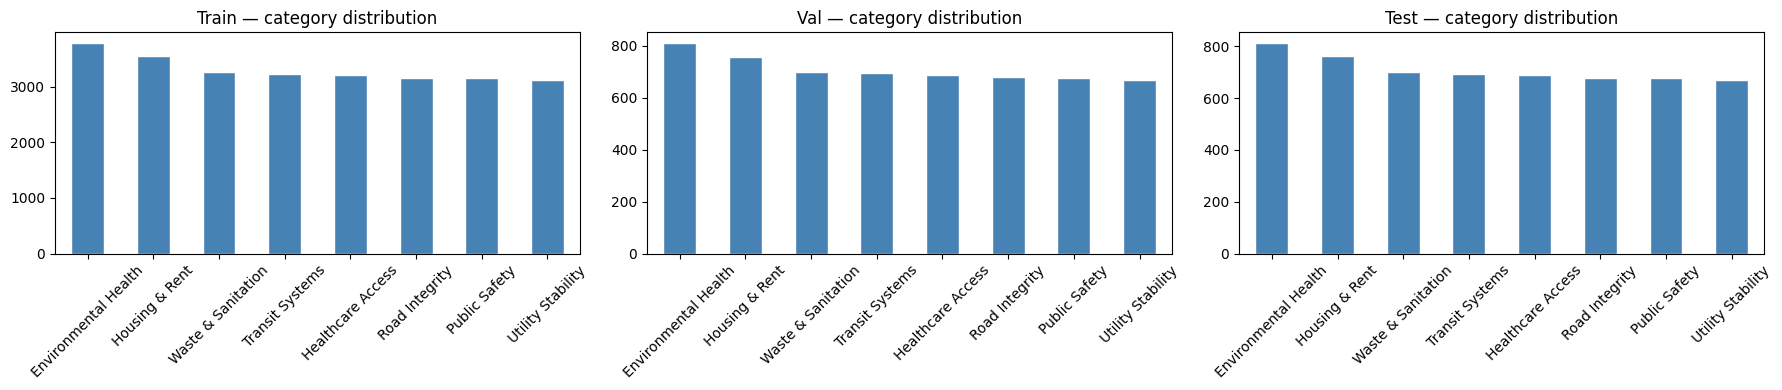

In [5]:
# Step 1: split off 70% train
df_train, df_temp = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['strat_key'], random_state=SEED
)

# Step 2: split remaining 30% equally into val and test (15/15)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5,
    stratify=df_temp['strat_key'], random_state=SEED
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'Train : {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val   : {len(df_val):,}   ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test  : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f}%)')

# Verify stratification held
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (split_df, name) in zip(axes, [(df_train,'Train'),(df_val,'Val'),(df_test,'Test')]):
    split_df[CATEGORY_COL].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{name} — category distribution')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 7 — Tokeniser & PyTorch Dataset

In [6]:
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

class UrbanIssueDataset(Dataset):
    """Returns input_ids, attention_mask, cat_label, sev_label (0-indexed)."""
    def __init__(self, dataframe, tokenizer, max_len=MAX_LEN):
        self.texts     = dataframe[TEXT_COL].tolist()
        self.cat_labels = dataframe['cat_label'].tolist()
        # Already 0-indexed: Low=0, Mid=1, High=2 (mapped in Cell 5)
        self.sev_labels = dataframe['sev_label'].tolist()
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'cat_label'      : torch.tensor(self.cat_labels[idx], dtype=torch.long),
            'sev_label'      : torch.tensor(self.sev_labels[idx], dtype=torch.long),
        }

train_dataset = UrbanIssueDataset(df_train, tokenizer)
val_dataset   = UrbanIssueDataset(df_val,   tokenizer)
test_dataset  = UrbanIssueDataset(df_test,  tokenizer)

print(f'Train samples : {len(train_dataset):,}')
print(f'Val samples   : {len(val_dataset):,}')
print(f'Test samples  : {len(test_dataset):,}')

# Quick sanity check
sample = train_dataset[0]
print(f'\nSample keys   : {list(sample.keys())}')
print(f'input_ids shape: {sample["input_ids"].shape}')

Train samples : 26,506
Val samples   : 5,680
Test samples  : 5,680

Sample keys   : ['input_ids', 'attention_mask', 'cat_label', 'sev_label']
input_ids shape: torch.Size([256])


## Cell 8 — Loss Functions

In [7]:
# ── Class-Balanced Focal Loss ─────────────────────────────────────────────────
class ClassBalancedFocalLoss(nn.Module):
    """
    Focal loss with per-class weights alpha_c.
    alpha_c is updated after Stage 1 via set_weights().
    """
    def __init__(self, num_classes, gamma=FOCAL_GAMMA, device=DEVICE):
        super().__init__()
        self.gamma       = gamma
        self.num_classes = num_classes
        # Uniform weights at init — overwritten after warm-up
        self.register_buffer(
            'alpha',
            torch.ones(num_classes, device=device) / num_classes
        )

    def set_weights(self, weights: np.ndarray):
        """Set dynamic class weights from isotonic re-weighting."""
        w = torch.tensor(weights, dtype=torch.float32, device=self.alpha.device)
        self.alpha = w / w.sum()   # normalise
        print(f'  CBF weights updated: {self.alpha.cpu().numpy().round(4)}')

    def forward(self, logits, targets, smoothing=0.1):
        # logits: (B, C)  targets: (B,)
        log_probs = F.log_softmax(logits, dim=-1)          # (B, C)
        probs     = log_probs.exp()                         # (B, C)
        target_log_probs = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)  # (B,)
        target_probs     = probs.gather(1, targets.unsqueeze(1)).squeeze(1)      # (B,)
        focal_weight     = (1.0 - target_probs) ** self.gamma                   # (B,)
        alpha_t          = self.alpha[targets]                                   # (B,)
        # Fix D: label smoothing — blend hard target with uniform distribution
        smooth_loss  = -log_probs.mean(dim=-1)             # (B,) uniform target
        hard_loss    = -target_log_probs                   # (B,) one-hot target
        smoothed_nll = (1 - smoothing) * hard_loss + smoothing * smooth_loss
        loss = alpha_t * focal_weight * smoothed_nll
        return loss.mean()


# ── Contrastive Prototype Separation Loss ─────────────────────────────────────
def prototype_contrastive_loss(proto_low, proto_high, margin=PROTO_MARGIN):
    """
    L_proto = max(0, margin - ||P3 - P1||_2)
    Pushes severity-3 centroid away from severity-1 centroid.
    """
    dist = torch.norm(proto_high - proto_low, p=2)
    return F.relu(margin - dist)


# ── Supervised Contrastive Loss (Fix 6) ───────────────────────────────────────
def supervised_contrastive_loss(embeddings, labels, temperature=0.07):
    """
    Pulls same-category embeddings together, pushes different-category apart.
    embeddings : (B, D) — [CLS] embeddings
    labels     : (B,)  — category labels
    temperature: scalar — lower = sharper contrast (0.07 is standard)
    """
    emb = F.normalize(embeddings, dim=1)                          # (B, D)
    similarity = torch.matmul(emb, emb.T) / temperature          # (B, B)

    labels_col = labels.unsqueeze(1)                              # (B, 1)
    mask = torch.eq(labels_col, labels_col.T).float()            # (B, B) — 1 if same class

    # Remove self-comparisons
    logits_mask = 1 - torch.eye(mask.shape[0], device=mask.device)
    mask = mask * logits_mask

    exp_sim  = torch.exp(similarity) * logits_mask               # exclude self
    log_prob = similarity - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)

    # Mean log-prob over positive pairs
    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-8)
    loss = -mean_log_prob_pos.mean()
    return loss


print('Loss functions defined.')

Loss functions defined.


## Cell 9 — Model Architecture

In [8]:
class UrbanIssueClassifier(nn.Module):
    """
    RoBERTa backbone v2 with:
      - Sigmoid attention (per-sample, not cross-batch)
      - Cosine similarity categorical head (label embeddings + projection)
      - MLP severity classifier (replaces CORN)
      - Prototype vector (initialised from severity centroids)
    """
    def __init__(
        self,
        model_name=MODEL_NAME,
        num_categories=NUM_CATEGORIES,
        num_severity=NUM_SEVERITY,
        hidden_dim=HIDDEN_DIM,
        tau_init=TAU_INIT,
        dropout=0.1,
    ):
        super().__init__()
        self.hidden_dim     = hidden_dim
        self.num_categories = num_categories
        self.num_severity   = num_severity

        # ── Backbone ──────────────────────────────────────────────────────────
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)

        # ── Severity prototype P_s ─────────────────────────────────────────
        self.prototype = nn.Parameter(torch.randn(hidden_dim) * 0.01)

        # ── MLP: concatenated centroids → single prototype ─────────────────
        self.proto_mlp = nn.Sequential(
            nn.Linear(3 * hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # ── Learnable temperature τ ────────────────────────────────────────
        self.log_tau = nn.Parameter(torch.tensor(float(np.log(tau_init))))

        # ── Fix 5: Cosine similarity categorical head ──────────────────────
        self.category_embeddings = nn.Parameter(
            torch.randn(num_categories, hidden_dim)
        )
        self.category_projection = nn.Linear(hidden_dim, hidden_dim)

        # ── Fix 3: MLP severity classifier (replaces CORN) ────────────────
        self.sev_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_severity)
        )

    # ─────────────────────────────────────────────────────────────────────────
    def init_prototype_from_centroids(self, centroids: dict):
        c_low  = centroids[0].to(next(self.parameters()).device)
        c_mid  = centroids[1].to(next(self.parameters()).device)
        c_high = centroids[2].to(next(self.parameters()).device)
        concat = torch.cat([c_low, c_mid, c_high], dim=0).unsqueeze(0)
        with torch.no_grad():
            proto = self.proto_mlp(concat).squeeze(0)
            self.prototype.data.copy_(proto)
        print('  Prototype initialised from severity centroids.')

    def init_label_embeddings(self, embeddings: torch.Tensor):
        with torch.no_grad():
            self.category_embeddings.data.copy_(embeddings)
        print('  Category embeddings initialised from category name encodings.')

    # ─────────────────────────────────────────────────────────────────────────
    def get_embedding(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        return self.dropout(cls_emb)

    def compute_attention_weights(self, embeddings):
        """
        Fix 1: Per-sample sigmoid attention.
        W_i = sigmoid(E_i · P_s / τ) — independent per post, not cross-batch.
        """
        tau     = self.log_tau.exp().clamp(min=0.1, max=10.0)
        proto_n = F.normalize(self.prototype, dim=0)
        emb_n   = F.normalize(embeddings.detach(), dim=-1)  # Fix C: detach so τ learns independently
        scores  = (emb_n @ proto_n) / tau
        return torch.sigmoid(scores)                       # (B,) per-sample

    def forward(self, input_ids, attention_mask):
        # 1. Backbone → [CLS] embedding
        E = self.get_embedding(input_ids, attention_mask)  # (B, 768)

        # 2. Per-sample sigmoid attention weights
        W = self.compute_attention_weights(E)              # (B,)

        # 3. Fix 5: Cosine similarity categorical head
        E_proj = self.category_projection(E)               # (B, 768)
        E_norm = F.normalize(E_proj, dim=-1)               # (B, 768)
        C_norm = F.normalize(self.category_embeddings, dim=-1)  # (C, 768)
        cat_logits = torch.matmul(E_norm, C_norm.T) * 20.0  # Fix B: scale 20.0 ≈ CLIP τ=0.05

        # 4. Fix 3: MLP severity classifier
        sev_logits = self.sev_classifier(E)                # (B, 3)

        return cat_logits, sev_logits, W, E


# Instantiate and display parameter count
model = UrbanIssueClassifier().to(DEVICE)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 12589.17it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters     : 128,196,868
Trainable parameters : 128,196,868


## Cell 10 — Stage 1: Warm-up Training (CBF Loss Only)

In [9]:
cbf_loss_fn = ClassBalancedFocalLoss(num_classes=NUM_CATEGORIES).to(DEVICE)

# Windows fix: num_workers=0 prevents multiprocessing spawn issues
# pin_memory=True + non_blocking transfers keep GPU fed efficiently
warmup_loader = DataLoader(
    train_dataset,
    batch_size=WARMUP_BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    generator=g   # ✅ add this
)

# 🔧 Split parameters for warm-up
roberta_params = list(model.roberta.parameters())
other_params   = [p for n, p in model.named_parameters() if "roberta" not in n]

trajectory_matrix = defaultdict(lambda: defaultdict(list))

for epoch in range(WARMUP_EPOCHS):
    # Freeze backbone first 2 epochs
    if epoch == 0:
        print("🔒 Freezing backbone...")
        for p in roberta_params:
            p.requires_grad = False
        warmup_optimizer = torch.optim.AdamW(other_params, lr=WARMUP_LR)
    # Unfreeze backbone starting epoch 2
    elif epoch == 2:
        print("🔓 Unfreezing backbone...")
        for p in roberta_params:
            p.requires_grad = True
        warmup_optimizer = torch.optim.AdamW(model.parameters(), lr=WARMUP_LR)

    model.train()
    total_loss = 0.0
    epoch_class_losses = defaultdict(list)

    pbar = tqdm(warmup_loader, desc=f'Warm-up Epoch {epoch+1}/{WARMUP_EPOCHS}')
    for batch in pbar:
        input_ids      = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        cat_labels     = batch['cat_label'].to(DEVICE, non_blocking=True)

        warmup_optimizer.zero_grad()
        cat_logits, _, _, _ = model(input_ids, attention_mask)

        loss = cbf_loss_fn(cat_logits, cat_labels, smoothing=0.1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        warmup_optimizer.step()

        total_loss += loss.item()

        # Track per-class loss
        per_sample_loss = (cbf_loss_fn.alpha[cat_labels] *
                           ((1.0 - F.softmax(cat_logits, dim=-1).gather(1, cat_labels.unsqueeze(1)).squeeze(1)) ** FOCAL_GAMMA) *
                           (-F.log_softmax(cat_logits, dim=-1).gather(1, cat_labels.unsqueeze(1)).squeeze(1))
                           ).detach().cpu()
        for cls_idx in range(NUM_CATEGORIES):
            mask = (cat_labels == cls_idx).cpu()
            if mask.any():
                epoch_class_losses[cls_idx].append(per_sample_loss[mask].mean().item())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Record epoch mean per class
    for cls_idx in range(NUM_CATEGORIES):
        vals = epoch_class_losses[cls_idx]
        trajectory_matrix[epoch][cls_idx] = np.mean(vals) if vals else 0.0

    avg_loss = total_loss / len(warmup_loader)
    print(f'  Epoch {epoch+1} avg loss: {avg_loss:.4f}')

print('\nWarm-up complete. Loss trajectories recorded.')

🔒 Freezing backbone...


Warm-up Epoch 1/5: 100%|██████████| 1657/1657 [02:56<00:00,  9.40it/s, loss=0.1950]


  Epoch 1 avg loss: 0.2126


Warm-up Epoch 2/5: 100%|██████████| 1657/1657 [02:55<00:00,  9.42it/s, loss=0.2046]


  Epoch 2 avg loss: 0.2077
🔓 Unfreezing backbone...


...

  Epoch 3 avg loss: 0.1905


Warm-up Epoch 4/5: 100%|██████████| 1657/1657 [08:40<00:00,  3.19it/s, loss=0.1177]


  Epoch 4 avg loss: 0.1125


Warm-up Epoch 5/5: 100%|██████████| 1657/1657 [08:44<00:00,  3.16it/s, loss=0.0657]

  Epoch 5 avg loss: 0.0766

Warm-up complete. Loss trajectories recorded.


## Cell 11 — Stage 2: Isotonic Re-weighting

Dynamic class weights α_c (isotonic re-weighting):
  [0] Environmental Health      asymptotic=0.0719  'instab=0.0023  α=0.1282
  [1] Housing & Rent            asymptotic=0.0708  'instab=0.0025  α=0.1264
  [2] Waste & Sanitation        asymptotic=0.0635  'instab=0.0044  α=0.1133
  [3] Transit Systems           asymptotic=0.0543  'instab=0.0041  α=0.0970
  [4] Healthcare Access         asymptotic=0.0362  'instab=0.0060  α=0.0647
  [5] Road Integrity            asymptotic=0.0625  'instab=0.0041  α=0.1116
  [6] Public Safety             asymptotic=0.1019  'instab=0.0022  α=0.1819
  [7] Utility Stability         asymptotic=0.0991  'instab=0.0024  α=0.1769
  CBF weights updated: [0.1282 0.1264 0.1133 0.097  0.0647 0.1116 0.1819 0.1769]


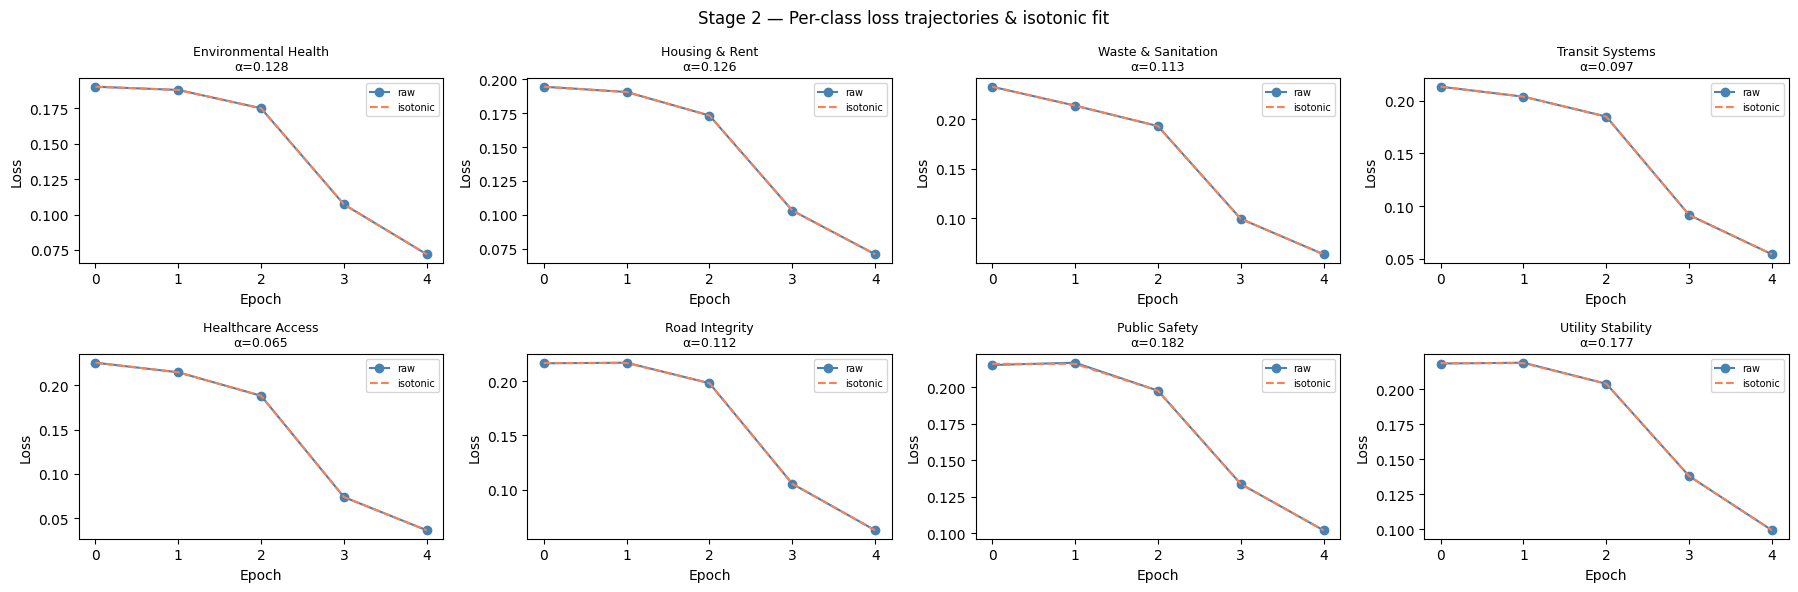

In [10]:
# Build trajectory array T ∈ R^(C × N_warmup_epochs)
T = np.zeros((NUM_CATEGORIES, WARMUP_EPOCHS))
for epoch in range(WARMUP_EPOCHS):
    for cls_idx in range(NUM_CATEGORIES):
        T[cls_idx, epoch] = trajectory_matrix[epoch][cls_idx]

# Fit isotonic regression per class and estimate asymptotic difficulty
epochs_x    = np.arange(WARMUP_EPOCHS, dtype=float)
asymptotic  = np.zeros(NUM_CATEGORIES)
instability = np.zeros(NUM_CATEGORIES)

iso = IsotonicRegression(increasing=False, out_of_bounds='clip')

for cls_idx in range(NUM_CATEGORIES):
    curve = T[cls_idx]
    if curve.sum() == 0:
        asymptotic[cls_idx]  = 0.01   # fallback for empty class
        instability[cls_idx] = 0.0
        continue
    fitted            = iso.fit_transform(epochs_x, curve)
    asymptotic[cls_idx]  = fitted[-1]           # last point = asymptotic estimate
    instability[cls_idx] = curve.var()

# Dynamic weight formula:
# α_c = (L̂_c(∞) · (1 + β·σ²_c)) / Σ_c' (L̂_c'(∞) · (1 + β·σ²_c'))
raw_weights = asymptotic * (1 + BETA_INSTAB * instability)
alpha_c     = raw_weights / raw_weights.sum()

print('Dynamic class weights α_c (isotonic re-weighting):')
for i, cat in enumerate(CATEGORIES):
    print(f'  [{i}] {cat:<25} asymptotic={asymptotic[i]:.4f}  \''
          f'instab={instability[i]:.4f}  α={alpha_c[i]:.4f}')

# Update the CBF loss function
cbf_loss_fn.set_weights(alpha_c)

# Visualise trajectories
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
for i, (ax, cat) in enumerate(zip(axes.flat, CATEGORIES)):
    ax.plot(T[i], 'o-', label='raw', color='steelblue')
    # Refit for plot
    if T[i].sum() > 0:
        fitted = IsotonicRegression(increasing=False).fit_transform(epochs_x, T[i])
        ax.plot(fitted, '--', label='isotonic', color='coral')
    ax.set_title(f'{cat}\nα={alpha_c[i]:.3f}', fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
plt.suptitle('Stage 2 — Per-class loss trajectories & isotonic fit', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'isotonic_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Stage 3: Prototype & Label Embedding Initialisation

In [11]:
print('=== Stage 3: Prototype & Label Embedding Initialisation ===')

# ── 3a. Freeze backbone for a single forward pass ─────────────────────────────
for param in model.roberta.parameters():
    param.requires_grad = False

model.eval()
severity_embeddings = defaultdict(list)   # {sev_idx: [tensors]}

init_loader = DataLoader(
    train_dataset, batch_size=16,  # reduced from 32 — 36k dataset needs less memory
    shuffle=False, num_workers=0, pin_memory=True
)

with torch.no_grad():
    for batch in tqdm(init_loader, desc='Computing severity centroids'):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        sev_labels     = batch['sev_label']           # 0-indexed on CPU

        emb = model.get_embedding(input_ids, attention_mask).cpu()  # (B, 768)

        for sev_idx in range(NUM_SEVERITY):
            mask = (sev_labels == sev_idx)
            if mask.any():
                severity_embeddings[sev_idx].append(emb[mask])

# Compute centroids P_s^(0)
centroids = {}
for sev_idx in range(NUM_SEVERITY):
    all_emb = torch.cat(severity_embeddings[sev_idx], dim=0)  # (N_sev, 768)
    centroids[sev_idx] = all_emb.mean(dim=0)                  # (768,)
    print(f'  Severity {sev_idx+1} centroid — n={all_emb.shape[0]:,}  '
          f'norm={centroids[sev_idx].norm():.3f}')

# ── 3b. Contrastive distance before initialisation ────────────────────────────
dist_before = (centroids[2] - centroids[0]).norm().item()
print(f'\n  ||P3 - P1||_2 before init: {dist_before:.4f}')

# ── 3c. Init prototype via MLP projection ─────────────────────────────────────
model.init_prototype_from_centroids(centroids)

# ── 3d. Label embedding initialisation ───────────────────────────────────────
# Encode each category name through the frozen RoBERTa
label_embs = []
with torch.no_grad():
    for cat_name in CATEGORIES:
        enc = tokenizer(
            cat_name, return_tensors='pt',
            padding='max_length', max_length=16, truncation=True
        ).to(DEVICE)
        out = model.roberta(**enc)
        cls_emb = out.last_hidden_state[:, 0, :]   # (1, 768)
        label_embs.append(cls_emb.squeeze(0).cpu())

label_emb_matrix = torch.stack(label_embs, dim=0)  # (8, 768)
model.init_label_embeddings(label_emb_matrix.to(DEVICE))

# ── 3e. Unfreeze backbone for main training ───────────────────────────────────
for param in model.roberta.parameters():
    param.requires_grad = True

print('\nStage 3 complete. Backbone unfrozen for main training.')

=== Stage 3: Prototype & Label Embedding Initialisation ===


Computing severity centroids: 100%|██████████| 1657/1657 [02:57<00:00,  9.32it/s]


  Severity 1 centroid — n=9,508  norm=13.117
  Severity 2 centroid — n=8,633  norm=13.147
  Severity 3 centroid — n=8,365  norm=13.099

  ||P3 - P1||_2 before init: 1.0048
  Prototype initialised from severity centroids.
  Category embeddings initialised from category name encodings.

Stage 3 complete. Backbone unfrozen for main training.


## Cell 13 — Stage 4: Main Training Loop

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=MAIN_BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    generator=g   # ✅ add this
)
val_loader = DataLoader(
    val_dataset, batch_size=MAIN_BATCH * 2,
    shuffle=False, num_workers=0, pin_memory=True
)

optimizer = torch.optim.AdamW(
    [
        {'params': model.roberta.parameters(),             'lr': MAIN_LR},
        {'params': model.proto_mlp.parameters(),           'lr': MAIN_LR * 5},
        {'params': [model.prototype, model.log_tau],       'lr': MAIN_LR * 5},
        {'params': model.category_embeddings,              'lr': MAIN_LR * 5},
        {'params': model.category_projection.parameters(), 'lr': MAIN_LR * 5},
        {'params': model.sev_classifier.parameters(),      'lr': MAIN_LR * 5},
    ],
    weight_decay=0.01
)

total_steps = len(train_loader) * MAIN_EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# ── Training history ──────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'val_cat_f1': [], 'val_sev_mae': [],
    'val_joint_acc': []
}

best_val_f1 = 0.0
best_model_path = OUTPUT_DIR / 'best_model.pt'


def evaluate(loader):
    model.eval()
    all_cat_preds, all_cat_true = [], []
    all_sev_preds, all_sev_true = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE, non_blocking=True)
            attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
            cat_labels     = batch['cat_label'].to(DEVICE, non_blocking=True)
            sev_labels     = batch['sev_label'].to(DEVICE, non_blocking=True)

            cat_logits, sev_logits, W, E = model(input_ids, attention_mask)

            # Fix 4: severity-aware category loss
            sev_weight = 1 + sev_labels.float() * SEV_WEIGHT_ALPHA
            l_cbf   = cbf_loss_fn(cat_logits, cat_labels) * sev_weight.mean()
            l_sev   = F.cross_entropy(sev_logits, sev_labels)
            mask_low  = (sev_labels == 0)
            mask_high = (sev_labels == 2)
            if mask_low.any() and mask_high.any():
                l_proto = prototype_contrastive_loss(
                    E[mask_low].mean(dim=0), E[mask_high].mean(dim=0)
                )
            else:
                l_proto = torch.tensor(0.0, device=DEVICE)
            loss = (LAMBDA_CBF * l_cbf + LAMBDA_SEV * l_sev + LAMBDA_PROTO * l_proto)
            total_loss += loss.item()

            # Predictions
            cat_preds = cat_logits.argmax(dim=-1).cpu().numpy()
            sev_preds = sev_logits.argmax(dim=-1).cpu().numpy()
            all_cat_preds.extend(cat_preds)
            all_cat_true.extend(cat_labels.cpu().numpy())
            all_sev_preds.extend(sev_preds)
            all_sev_true.extend(sev_labels.cpu().numpy())

    all_cat_preds = np.array(all_cat_preds)
    all_cat_true  = np.array(all_cat_true)
    all_sev_preds = np.array(all_sev_preds)
    all_sev_true  = np.array(all_sev_true)

    cat_f1    = f1_score(all_cat_true, all_cat_preds, average='macro')
    sev_mae   = mean_absolute_error(all_sev_true, all_sev_preds)
    joint_acc = np.mean(
        (all_cat_preds == all_cat_true) & (all_sev_preds == all_sev_true)
    )
    return total_loss / len(loader), cat_f1, sev_mae, joint_acc


# ── Main training loop ────────────────────────────────────────────────────────
print('=== Stage 4: Main Training v2 ===')
for epoch in range(MAIN_EPOCHS):
    model.train()
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{MAIN_EPOCHS}')
    for batch in pbar:
        input_ids      = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        cat_labels     = batch['cat_label'].to(DEVICE, non_blocking=True)
        sev_labels     = batch['sev_label'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        cat_logits, sev_logits, W, E = model(input_ids, attention_mask)

        # Fix 4: severity-aware category loss
        sev_weight = 1 + sev_labels.float() * SEV_WEIGHT_ALPHA
        l_cbf = cbf_loss_fn(cat_logits, cat_labels) * sev_weight.mean()

        # Fix 3: MLP severity cross-entropy
        l_sev = F.cross_entropy(sev_logits, sev_labels)

        # Prototype contrastive (batch centroids)
        mask_low  = (sev_labels == 0)
        mask_high = (sev_labels == 2)
        if mask_low.any() and mask_high.any():
            l_proto = prototype_contrastive_loss(
                E[mask_low].mean(dim=0), E[mask_high].mean(dim=0)
            )
        else:
            l_proto = torch.tensor(0.0, device=DEVICE)

        # Fix 6: supervised contrastive loss on category embeddings
        l_contrast = supervised_contrastive_loss(E, cat_labels)

        loss = (LAMBDA_CBF     * l_cbf     +
                LAMBDA_SEV     * l_sev     +
                LAMBDA_PROTO   * l_proto   +
                LAMBDA_CONTRAST * l_contrast)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        pbar.set_postfix({
            'loss'  : f'{loss.item():.4f}',
            'l_cbf' : f'{l_cbf.item():.3f}',
            'l_sev' : f'{l_sev.item():.3f}',
            'l_con' : f'{l_contrast.item():.3f}',
            'τ'     : f'{model.log_tau.exp().item():.3f}'
        })

    val_loss, val_cat_f1, val_sev_mae, val_joint_acc = evaluate(val_loader)
    avg_train_loss = train_loss / len(train_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_cat_f1'].append(val_cat_f1)
    history['val_sev_mae'].append(val_sev_mae)
    history['val_joint_acc'].append(val_joint_acc)

    print(f'  Epoch {epoch+1:02d} | '
          f'train_loss={avg_train_loss:.4f} | '
          f'val_loss={val_loss:.4f} | '
          f'cat_F1={val_cat_f1:.4f} | '
          f'sev_MAE={val_sev_mae:.4f} | '
          f'joint_acc={val_joint_acc:.4f}')

    if val_cat_f1 > best_val_f1:
        best_val_f1 = val_cat_f1
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'val_cat_f1'  : val_cat_f1,
            'val_sev_mae' : val_sev_mae,
            'alpha_c'     : alpha_c,
        }, best_model_path)
        print(f'  ✓ Best model saved (val F1={val_cat_f1:.4f})')

print('\nMain training complete.')

=== Stage 4: Main Training v2 ===


Epoch 1/20: 100%|██████████| 1657/1657 [08:45<00:00,  3.15it/s, loss=0.4081, l_cbf=0.084, l_sev=0.514, l_con=0.666, τ=1.000]


  Epoch 01 | train_loss=0.7670 | val_loss=0.3759 | cat_F1=0.7792 | sev_MAE=0.2431 | joint_acc=0.5842
  ✓ Best model saved (val F1=0.7792)


Epoch 2/20: 100%|██████████| 1657/1657 [08:45<00:00,  3.15it/s, loss=0.3412, l_cbf=0.034, l_sev=0.490, l_con=0.624, τ=1.000]


  Epoch 02 | train_loss=0.5207 | val_loss=0.3279 | cat_F1=0.7830 | sev_MAE=0.2077 | joint_acc=0.6252
  ✓ Best model saved (val F1=0.7830)


...

  Epoch 18 | train_loss=0.1095 | val_loss=0.5012 | cat_F1=0.8574 | sev_MAE=0.1289 | joint_acc=0.7474
  ✓ Best model saved (val F1=0.8574)


Epoch 19/20: 100%|██████████| 1657/1657 [08:47<00:00,  3.14it/s, loss=0.0399, l_cbf=0.000, l_sev=0.031, l_con=0.242, τ=1.000]


  Epoch 19 | train_loss=0.1030 | val_loss=0.4881 | cat_F1=0.8577 | sev_MAE=0.1238 | joint_acc=0.7514
  ✓ Best model saved (val F1=0.8577)


Epoch 20/20: 100%|██████████| 1657/1657 [08:48<00:00,  3.14it/s, loss=0.0232, l_cbf=0.000, l_sev=0.000, l_con=0.230, τ=1.000]


  Epoch 20 | train_loss=0.0959 | val_loss=0.4902 | cat_F1=0.8606 | sev_MAE=0.1227 | joint_acc=0.7549
  ✓ Best model saved (val F1=0.8606)

Main training complete.


## Cell 14 — Training Curves

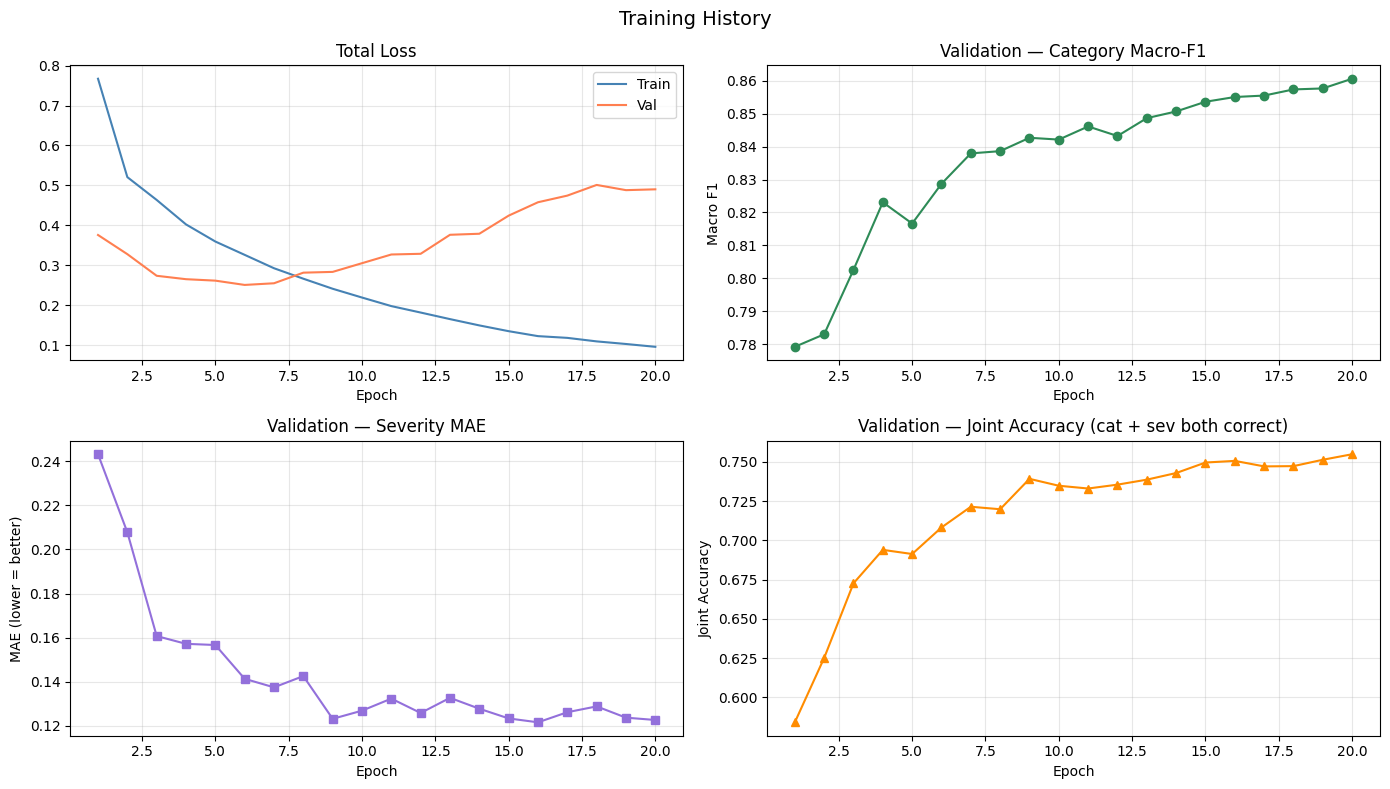

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
epochs_x = range(1, MAIN_EPOCHS + 1)

axes[0,0].plot(epochs_x, history['train_loss'], label='Train', color='steelblue')
axes[0,0].plot(epochs_x, history['val_loss'],   label='Val',   color='coral')
axes[0,0].set_title('Total Loss'); axes[0,0].legend()

axes[0,1].plot(epochs_x, history['val_cat_f1'], color='seagreen', marker='o')
axes[0,1].set_title('Validation — Category Macro-F1')
axes[0,1].set_ylabel('Macro F1')

axes[1,0].plot(epochs_x, history['val_sev_mae'], color='mediumpurple', marker='s')
axes[1,0].set_title('Validation — Severity MAE')
axes[1,0].set_ylabel('MAE (lower = better)')

axes[1,1].plot(epochs_x, history['val_joint_acc'], color='darkorange', marker='^')
axes[1,1].set_title('Validation — Joint Accuracy (cat + sev both correct)')
axes[1,1].set_ylabel('Joint Accuracy')

for ax in axes.flat:
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 15 — Test Set Evaluation

In [14]:
# Load best checkpoint
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Val Cat F1 at save: {checkpoint['val_cat_f1']:.4f}")

test_loader = DataLoader(
    test_dataset, batch_size=MAIN_BATCH * 2,
    shuffle=False, num_workers=0, pin_memory=True
)

model.eval()
all_cat_preds, all_cat_true = [], []
all_sev_preds, all_sev_true = [], []
all_attention_weights       = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test inference'):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        cat_labels     = batch['cat_label']
        sev_labels     = batch['sev_label']

        cat_logits, sev_logits, W, _ = model(input_ids, attention_mask)

        # Category
        cat_preds = cat_logits.argmax(dim=-1).cpu().numpy()
        all_cat_preds.extend(cat_preds)
        all_cat_true.extend(cat_labels.numpy())

        # Fix 3: direct MLP severity prediction
        sev_preds = sev_logits.argmax(dim=-1).cpu().numpy()
        all_sev_preds.extend(sev_preds)
        all_sev_true.extend(sev_labels.numpy())

        all_attention_weights.extend(W.cpu().numpy())

all_cat_preds = np.array(all_cat_preds)
all_cat_true  = np.array(all_cat_true)
all_sev_preds = np.array(all_sev_preds)
all_sev_true  = np.array(all_sev_true)

print('\n' + '='*60)
print('TEST SET RESULTS')
print('='*60)

# Category metrics
cat_macro_f1  = f1_score(all_cat_true, all_cat_preds, average='macro')
cat_weighted_f1 = f1_score(all_cat_true, all_cat_preds, average='weighted')
cat_acc       = accuracy_score(all_cat_true, all_cat_preds)
sev_mae       = mean_absolute_error(all_sev_true, all_sev_preds)
sev_acc       = accuracy_score(all_sev_true, all_sev_preds)
joint_acc     = np.mean(
    (all_cat_preds == all_cat_true) & (all_sev_preds == all_sev_true)
)

print(f'\n[Category Head]')
print(f'  Macro F1         : {cat_macro_f1:.4f}')
print(f'  Weighted F1      : {cat_weighted_f1:.4f}')
print(f'  Accuracy         : {cat_acc:.4f}')

print(f'\n[Severity Head]')
print(f'  MAE              : {sev_mae:.4f}')
print(f'  Exact Accuracy   : {sev_acc:.4f}')

print(f'\n[Joint Metric]')
print(f'  Joint Accuracy   : {joint_acc:.4f}  (both cat + sev correct)')

print('\n[Per-class Category Report]')
print(classification_report(
    all_cat_true, all_cat_preds, target_names=CATEGORIES, digits=4
))

Loaded best model from epoch 20
Val Cat F1 at save: 0.8606


Test inference: 100%|██████████| 178/178 [00:36<00:00,  4.91it/s]


TEST SET RESULTS

[Category Head]
  Macro F1         : 0.8594
  Weighted F1      : 0.8601
  Accuracy         : 0.8597

[Severity Head]
  MAE              : 0.1194
  Exact Accuracy   : 0.8861

[Joint Metric]
  Joint Accuracy   : 0.7579  (both cat + sev correct)

[Per-class Category Report]
                      precision    recall  f1-score   support

Environmental Health     0.8665    0.8782    0.8723       813
      Housing & Rent     0.8788    0.8292    0.8533       761
  Waste & Sanitation     0.8622    0.8745    0.8683       701
     Transit Systems     0.9303    0.8860    0.9076       693
   Healthcare Access     0.9438    0.9507    0.9472       689
      Road Integrity     0.8831    0.8818    0.8825       677
       Public Safety     0.7634    0.7770    0.7701       677
   Utility Stability     0.7528    0.7967    0.7741       669

            accuracy                         0.8597      5680
           macro avg     0.8601    0.8593    0.8594      5680
        weighted avg     

## Cell 16 — Confusion Matrices

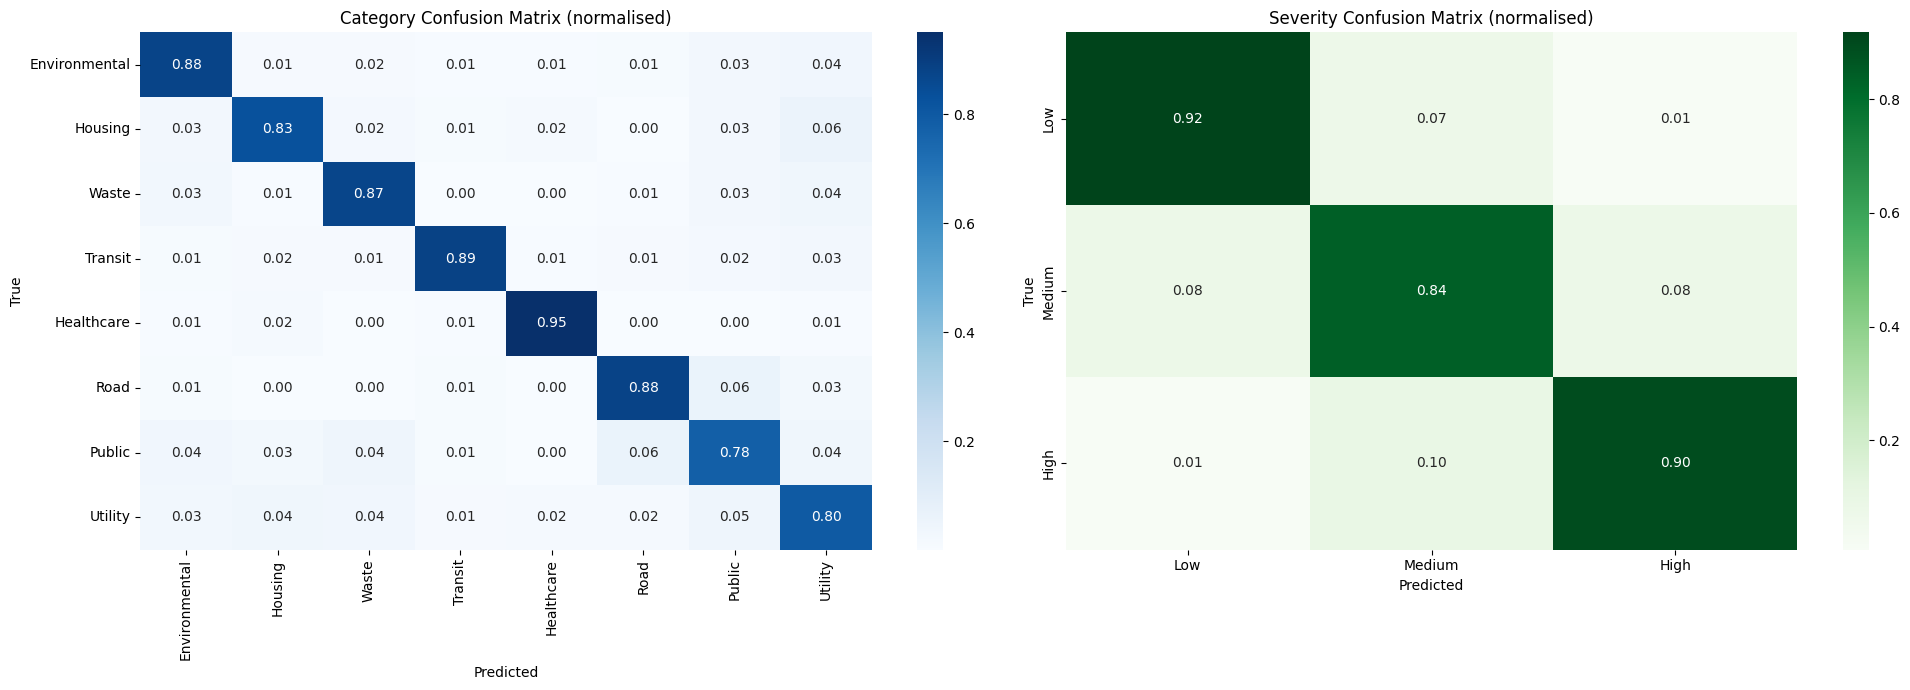

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Category confusion matrix
cm_cat = confusion_matrix(all_cat_true, all_cat_preds, normalize='true')
sns.heatmap(
    cm_cat, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=[c.split()[0] for c in CATEGORIES],
    yticklabels=[c.split()[0] for c in CATEGORIES],
    ax=axes[0]
)
axes[0].set_title('Category Confusion Matrix (normalised)', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Severity confusion matrix
cm_sev = confusion_matrix(all_sev_true, all_sev_preds, normalize='true')
sns.heatmap(
    cm_sev, annot=True, fmt='.2f', cmap='Greens',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High'],
    ax=axes[1]
)
axes[1].set_title('Severity Confusion Matrix (normalised)', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 17 — Attention Weight Analysis

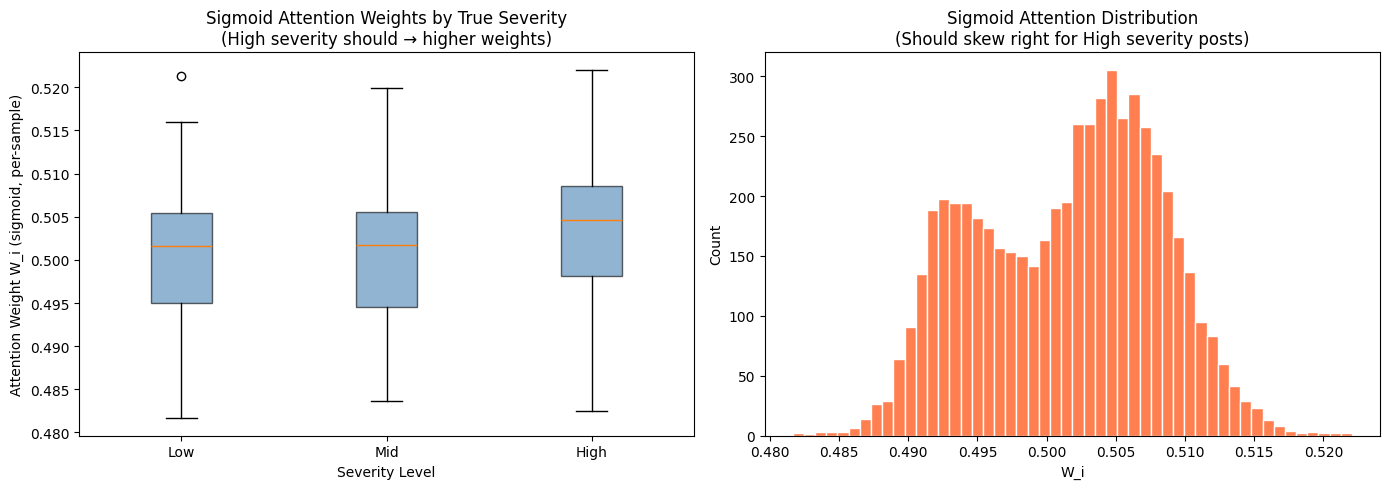

Mean sigmoid attention weight by severity level:
  Low: 0.500509  (n=2,039)
  Medium: 0.500510  (n=1,851)
  High: 0.503605  (n=1,790)

Learned temperature τ: 1.0000


In [16]:
# Verify that higher severity posts receive higher attention weights (model sanity check)
# With sigmoid attention, weights are in [0,1] per-sample independently
attn_weights = np.array(all_attention_weights)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: attention weight by severity (0=Low, 1=Mid, 2=High)
sev_attn = {0: [], 1: [], 2: []}
for w, s in zip(attn_weights, all_sev_true):
    sev_attn[int(s)].append(w)

axes[0].boxplot(
    [sev_attn[0], sev_attn[1], sev_attn[2]],
    labels=['Low', 'Mid', 'High'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[0].set_title('Sigmoid Attention Weights by True Severity\n(High severity should → higher weights)')
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Attention Weight W_i (sigmoid, per-sample)')

# Distribution of W_i — sigmoid weights cluster around 0.5 if balanced
axes[1].hist(attn_weights, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Sigmoid Attention Distribution\n(Should skew right for High severity posts)')
axes[1].set_xlabel('W_i')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'attention_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Mean attention by severity — should increase Low → Mid → High
print('Mean sigmoid attention weight by severity level:')
for idx, label in enumerate(SEVERITY_LABELS):
    vals = sev_attn[idx]
    print(f'  {label}: {np.mean(vals):.6f}  (n={len(vals):,})')

print(f'\nLearned temperature τ: {model.log_tau.exp().item():.4f}')

## Cell 18 — Save Results & Summary

In [ ]:
results = {
    'model'         : MODEL_NAME,
    'max_len'       : MAX_LEN,
    'warmup_epochs' : WARMUP_EPOCHS,
    'main_epochs'   : MAIN_EPOCHS,
    'lambdas'       : {'cbf': LAMBDA_CBF, 'sev': LAMBDA_SEV,
                       'proto': LAMBDA_PROTO, 'contrast': LAMBDA_CONTRAST},
    'test_metrics'  : {
        'cat_macro_f1'    : round(cat_macro_f1, 4),
        'cat_weighted_f1' : round(cat_weighted_f1, 4),
        'cat_accuracy'    : round(cat_acc, 4),
        'sev_mae'         : round(sev_mae, 4),
        'sev_accuracy'    : round(sev_acc, 4),
        'joint_accuracy'  : round(joint_acc, 4),
    },
    'dynamic_class_weights': {
        cat: round(float(alpha_c[i]), 4)
        for i, cat in enumerate(CATEGORIES)
    },
    'learned_tau'   : round(model.log_tau.exp().item(), 4),
}

with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Results saved to outputs/results.json')
print('\n' + '='*60)
print('FINAL SUMMARY')
print('='*60)
print(f"  Category Macro-F1  : {results['test_metrics']['cat_macro_f1']}")
print(f"  Category Weighted-F1: {results['test_metrics']['cat_weighted_f1']}")
print(f"  Severity MAE        : {results['test_metrics']['sev_mae']}")
print(f"  Severity Accuracy   : {results['test_metrics']['sev_accuracy']}")
print(f"  Joint Accuracy      : {results['test_metrics']['joint_accuracy']}")
print(f"  Learned τ           : {results['learned_tau']}")
print('\nOutput files:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f}')